In [1]:
from pandas_datareader import data as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt
from alpha_vantage.timeseries import TimeSeries
import backtrader as btr
import yfinance as yf
import bt
import time

In [35]:

API_key = "WOTD4SDGAPUFM7QL"

ts = TimeSeries(key=API_key, output_format="pandas")
alpha_vantage = ts.get_daily("AAPL")
apple_stock_data = alpha_vantage[0] #it gives the data from the tuple
apple_stock_data = apple_stock_data.iloc[::-1]  # Reverse row order

meta_data = alpha_vantage[1] #it takes the meta data from the tuple

#alpha_vantage[0].to_csv("/Users/ushasthej/Visual_studio/Python for Finance_Udemy/alpha.csv")
#alpha_vantage[0].to_excel("/Users/ushasthej/Visual_studio/Python for Finance_Udemy/alpha.xlsx")
#beta = pd.read_csv("/Users/ushasthej/Visual_studio/Python for Finance_Udemy/alpha.csv")
#gamma = pd.read_csv("/Users/ushasthej/Visual_studio/Python for Finance_Udemy/alpha.csv", index_col="date")
#beta = pd.read_excel("/Users/ushasthej/Visual_studio/Python for Finance_Udemy/alpha.xlsx")
#beta.tail()

In [36]:
def safe_download(ticker, start, end, max_retries=5):
    for i in range(max_retries):
        try:
            data = yf.download(ticker, start=start, end=end)
            if not data.empty:
                return data
        except Exception as e:
            print(f"Attempt {i+1} failed: {e}")
            time.sleep(2 ** i)  # exponential backoff
    raise RuntimeError(f"Failed to download {ticker} after {max_retries} attempts.")

In [37]:
apple_stock_data = safe_download("AAPL", "2022-01-01", "2024-12-31")

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


RuntimeError: Failed to download AAPL after 5 attempts.

In [2]:
apple_stock_data = pd.read_csv("/Users/ushasthej/Visual_studio/AAPL.csv", skiprows=[1,2])
apple_stock_data.rename(columns={"Price": "Date"}, inplace=True)
apple_stock_data

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
1,2020-01-03,71.833305,72.594071,71.608700,71.765682,146322800
2,2020-01-06,72.405685,72.444328,70.703020,70.954195,118387200
3,2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000
4,2020-01-08,73.224419,73.526310,71.768094,71.768094,132079200
...,...,...,...,...,...,...
1413,2025-08-18,230.889999,233.119995,230.110001,231.699997,37476200
1414,2025-08-19,230.559998,232.869995,229.350006,231.279999,39402600
1415,2025-08-20,226.009995,230.470001,225.770004,229.979996,42263900
1416,2025-08-21,224.899994,226.520004,223.779999,226.270004,30621200


In [3]:
apple_stock_data['Date'] = pd.to_datetime(apple_stock_data['Date'])
apple_stock_data.set_index('Date', inplace=True)

In [4]:
apple_stock_data

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833305,72.594071,71.608700,71.765682,146322800
2020-01-06,72.405685,72.444328,70.703020,70.954195,118387200
2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000
2020-01-08,73.224419,73.526310,71.768094,71.768094,132079200
...,...,...,...,...,...
2025-08-18,230.889999,233.119995,230.110001,231.699997,37476200
2025-08-19,230.559998,232.869995,229.350006,231.279999,39402600
2025-08-20,226.009995,230.470001,225.770004,229.979996,42263900


In [5]:
volume = apple_stock_data[['Volume']]
apple_stock_data['simple_return'] = apple_stock_data['Close'].pct_change()
apple_stock_data = apple_stock_data.replace([np.inf, -np.inf], np.nan).dropna()

In [6]:
window = 20 #number of trading days
apple_stock_data['rolling_volatility'] = apple_stock_data['simple_return'].rolling(window=window).std()
apple_stock_data = apple_stock_data.replace([np.inf, -np.inf], np.nan).dropna()
apple_stock_data

,Close,High,Low,Open,Volume,simple_return,rolling_volatility
Date,,,,,,,
2020-01-31,74.750771,77.931496,74.456124,77.508848,199588400,-0.044339,0.017679
2020-02-03,74.545509,75.712016,72.990163,73.492507,173788400,-0.002746,0.017511
2020-02-04,77.006516,77.197313,75.745816,76.151556,136616400,0.033013,0.018808
2020-02-05,77.634460,78.433869,77.030677,78.134387,118826800,0.008154,0.018741
2020-02-06,78.542526,78.544944,77.347040,77.904935,105425600,0.011697,0.018616
...,...,...,...,...,...,...,...
2025-08-18,230.889999,233.119995,230.110001,231.699997,37476200,-0.003023,0.018591
2025-08-19,230.559998,232.869995,229.350006,231.279999,39402600,-0.001429,0.018601
2025-08-20,226.009995,230.470001,225.770004,229.979996,42263900,-0.019735,0.019314


In [7]:
data = apple_stock_data.copy()
def avg_true_range(datas, win = 14):
    high_low = datas['High'] - datas['Low']
    high_close = abs(datas['High'] - datas['Close'].shift())
    low_close = abs(datas['Low'] - datas['Close'].shift())
    true_range = pd.concat([high_low, high_close, low_close], axis = 1).max(axis = 1)
    return true_range.rolling(window=win).mean()

apple_stock_data['avg_true_value'] = avg_true_range(data)
apple_stock_data = apple_stock_data.replace([np.inf, -np.inf], np.nan).dropna()
apple_stock_data

,Close,High,Low,Open,Volume,simple_return,rolling_volatility,avg_true_value
Date,,,,,,,,
2020-02-20,77.540306,78.593384,77.034346,78.104372,100566000,-0.010259,0.019060,1.792613
2020-02-21,75.785164,77.576610,75.167846,77.133587,129554000,-0.022635,0.019725,1.716427
2020-02-24,72.185341,73.637860,70.018671,71.962625,222195200,-0.047500,0.022338,1.933901
2020-02-25,69.740265,73.238417,69.268201,72.855924,230673600,-0.033872,0.022637,2.028073
2020-02-26,70.846588,72.112703,69.357758,69.365020,198054800,0.015863,0.021888,2.122901
...,...,...,...,...,...,...,...,...
2025-08-18,230.889999,233.119995,230.110001,231.699997,37476200,-0.003023,0.018591,6.189377
2025-08-19,230.559998,232.869995,229.350006,231.279999,39402600,-0.001429,0.018601,6.107612
2025-08-20,226.009995,230.470001,225.770004,229.979996,42263900,-0.019735,0.019314,6.258543


In [8]:
atr_data = apple_stock_data[['Close', 'simple_return', 'rolling_volatility', 'avg_true_value']]
atr_data['signal'] = np.zeros(len(atr_data['Close']))
atr_data['signal_vol'] = np.zeros(len(atr_data['Close']))
atr_data

/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/3784449311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atr_data['signal'] = np.zeros(len(atr_data['Close']))
/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/3784449311.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  atr_data['signal_vol'] = np.zeros(len(atr_data['Close']))


,Close,simple_return,rolling_volatility,avg_true_value,signal,signal_vol
Date,,,,,,
2020-02-20,77.540306,-0.010259,0.019060,1.792613,0.0,0.0
2020-02-21,75.785164,-0.022635,0.019725,1.716427,0.0,0.0
2020-02-24,72.185341,-0.047500,0.022338,1.933901,0.0,0.0
2020-02-25,69.740265,-0.033872,0.022637,2.028073,0.0,0.0
2020-02-26,70.846588,0.015863,0.021888,2.122901,0.0,0.0
...,...,...,...,...,...,...
2025-08-18,230.889999,-0.003023,0.018591,6.189377,0.0,0.0
2025-08-19,230.559998,-0.001429,0.018601,6.107612,0.0,0.0
2025-08-20,226.009995,-0.019735,0.019314,6.258543,0.0,0.0


In [9]:
datas = atr_data.copy()
# Defining thresholds
# Compute rolling metrics
vol_threshold_data = datas['rolling_volatility'].rolling(window=10).mean()
volume_threshold_data = datas['avg_true_value'].rolling(window=10).mean()
rolling_mean_10 = datas['Close'].rolling(window=10).mean()
rolling_max_10 = datas['Close'].rolling(window=10).max()

# Remove first 9 rows (NaN values from rolling)
datas = datas.iloc[9:]  # Copy to avoid modifying the original DataFrame
rolling_mean_10 = rolling_mean_10.iloc[9:]
rolling_max_10 = rolling_max_10.iloc[9:]
volume_threshold_data = volume_threshold_data.iloc[9:]
vol_threshold_data = vol_threshold_data.iloc[9:]

# Ensure the signal column exists
if 'signal' not in datas.columns:
    datas['signal'] = np.nan

for i in range(datas.shape[0]):  
    # Extract single values (scalars)
    rolling_mean_value = rolling_mean_10.iloc[i].item()  # No .item(), just iloc
    rolling_max_value = rolling_max_10.iloc[i].item()
    volume_threshold = volume_threshold_data.iloc[i].item()
    vol_threshold = vol_threshold_data.iloc[i].item()

    # Short signal using ATR
    if datas['avg_true_value'].iloc[i].item() < volume_threshold:
        if datas['Close'].iloc[i].item() < rolling_mean_value:
            datas.iloc[i, datas.columns.get_loc('signal')] = -1.0
    
    # Long signal using ATR
    else:
        if datas['Close'].iloc[i].item() >= rolling_max_value:
            datas.iloc[i, datas.columns.get_loc('signal')] = 1.0

    # Short signal
    if datas['rolling_volatility'].iloc[i].item() < vol_threshold:
        if datas['Close'].iloc[i].item() < rolling_mean_value:
            datas.iloc[i, datas.columns.get_loc('signal_vol')] = -1.0
    
    # Long signal
    else:
        if datas['Close'].iloc[i].item() >= rolling_max_value:
            datas.iloc[i, datas.columns.get_loc('signal_vol')] = 1.0



atr_signal = datas.copy()

atr_signal#['signal'].value_counts()

,Close,simple_return,rolling_volatility,avg_true_value,signal,signal_vol
Date,,,,,,
2020-03-04,73.289246,0.046384,0.033955,3.336821,0.0,0.0
2020-03-05,70.911957,-0.032437,0.034529,3.466164,0.0,0.0
2020-03-06,69.970253,-0.013280,0.034384,3.614181,0.0,0.0
2020-03-09,64.436188,-0.079092,0.038139,3.885486,0.0,0.0
2020-03-10,69.076958,0.072021,0.042126,4.139672,0.0,0.0
...,...,...,...,...,...,...
2025-08-18,230.889999,-0.003023,0.018591,6.189377,0.0,0.0
2025-08-19,230.559998,-0.001429,0.018601,6.107612,0.0,0.0
2025-08-20,226.009995,-0.019735,0.019314,6.258543,0.0,0.0


backtest 1

In [29]:
def backtest_strategy(datas2: pd.DataFrame):
    #calculate position and strategy returns, tarding the next day after signal
    datas2['simple_returns1'] = (datas2['Close']/datas2['Close'].shift()) - 1
    datas2['position'] = datas2['signal_vol'].ffill()
    datas2['strategy_returns'] = datas2['position'].shift(1) * datas2['simple_returns1']  
    
    return datas2

atr_strategy = backtest_strategy(atr_signal).fillna(0)
atr_strategy['strategy_returns'].value_counts()

strategy_returns
 0.000000    954
-0.000694      1
 0.005405      1
-0.013341      1
-0.003484      1
            ... 
 0.008538      1
-0.034997      1
 0.011676      1
 0.023717      1
-0.002357      1
Name: count, Length: 423, dtype: int64

------------------------------------
RSI strategy returns: -0.2295255889924458
Stock returns: 1.4604940476748554
------------------------------------


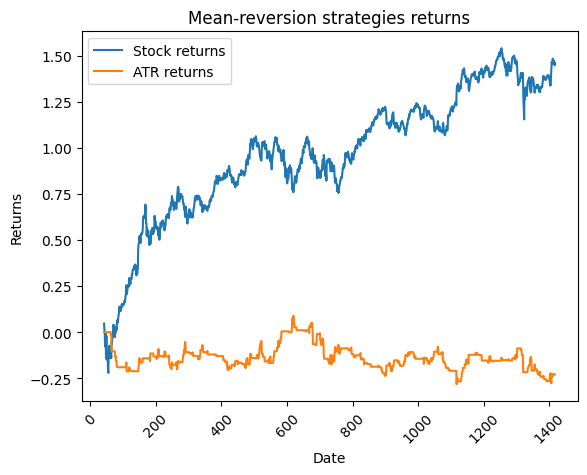

In [30]:
print('------------------------------------')
print("RSI strategy returns:", atr_strategy['strategy_returns'].cumsum().iloc[-1])
print("Stock returns:", atr_strategy['simple_return'].cumsum().iloc[-1])
print('------------------------------------')

#pt.figure(figsize=(12,5))
pt.plot(atr_strategy.index, atr_strategy['simple_return'].cumsum(), label = 'Stock returns')
pt.plot(atr_strategy.index, atr_strategy['strategy_returns'].cumsum(), label = 'ATR returns')
pt.title('Mean-reversion strategies returns')
pt.xlabel('Date')
pt.ylabel('Returns')
pt.xticks(rotation=45)
pt.legend()
pt.show()

Short position open at 58.32105255126953 on 2020-04-01 00:00:00
Short position closed at 59.294227600097656 on 2020-04-02 00:00:00
Short position open at 58.44208526611328 on 2020-04-03 00:00:00
Short position closed at 63.540435791015625 on 2020-04-06 00:00:00
Short position open at 64.96875 on 2020-04-21 00:00:00
Short position closed at 66.8400650024414 on 2020-04-22 00:00:00
Short position open at 66.8400650024414 on 2020-04-22 00:00:00
Short position closed at 68.50321197509766 on 2020-04-24 00:00:00
Short position open at 66.58103942871094 on 2020-04-23 00:00:00
Short position closed at 68.50321197509766 on 2020-04-24 00:00:00
Short position open at 67.44044494628906 on 2020-04-28 00:00:00
Short position closed at 69.65552520751953 on 2020-04-29 00:00:00
Long position open at 77.49044799804688 on 2020-05-20 00:00:00
Long position closed at 76.9127426147461 on 2020-05-21 00:00:00
Long position open at 85.64901733398438 on 2020-06-10 00:00:00
Long position closed at 81.536964416503

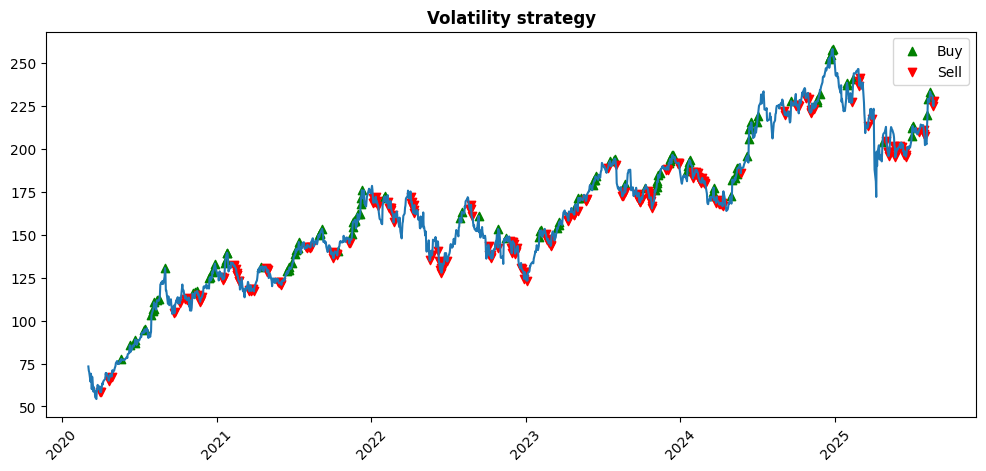

In [13]:
def backtest_strategy_alt(data: pd.DataFrame):
    # Ensure index is in datetime format
    data.index = pd.to_datetime(data.index)

    position = False
    price_change = []

    for i in data.index:
        if i not in data.index:
            print(f"Skipping missing date: {i}")
            continue  # Skip missing dates

        price = data.loc[i, "Close"].item()
        date = i
        i_pos = data.index.get_loc(i)  # Get integer position of i

        # Long position
        if (data.loc[i, "signal"].item() == 1) and (not position):
            buy_price = price
            position = True
            data.at[i, 'buy_date'] = date
            print(f"Long position open at {buy_price} on {date}")

            #close position after 15% profit or 3% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = (market_price/price) - 1
                if k < (i_pos + 46):
                    if (percent >= 0.05) and position:
                        price_change.append(percent)
                        position = False
                        print(f"Long position closed at {market_price} on {data.index[k]}")
                        break
                
                    elif (percent <= -0.005) and position:
                        price_change.append(percent)
                        position = False
                        print(f"Long position closed at {market_price} on {data.index[k]}")
                        break

                else:
                    price_change.append(percent)
                    position = False
                    print(f"Long position closed at {market_price} on {data.index[k]}")
                    break


        # Short position
        elif (data.loc[i, "signal"].item() == -1) and (not position):
            sell_price = price
            position = True
            data.at[i, 'sell_date'] = date
            print(f"Short position open at {sell_price} on {date}")

            #close position after 5% profit or 1% loss or close immediately after a span of 45 days from the position opening
            for k in range(i_pos + 1, min(i_pos + 46, len(data))):
                market_price = data["Close"].iloc[k].item()
                percent = 1 - (market_price/price)
                if k < (i_pos + 46):
                    if (percent >= 0.05) and position:
                        price_change.append(percent)
                        position = False
                        print(f"Short position closed at {market_price} on {data.index[k]}")
                        break
                
                    elif (percent <= -0.005) and position == True:
                        price_change.append(percent)
                        position = False
                        print(f"Short position closed at {market_price} on {data.index[k]}")
                        break

                else:
                    price_change.append(percent)
                    position = False
                    print(f"Short position closed at {market_price} on {data.index[k]}")
                    break

    trades_count = len(price_change)
    won_trades = sum(1 for x in price_change if x > 0)
    lost_trades = sum(1 for x in price_change if x < 0)

    # Recursively calculate return
    def calculate_return(total_return, price_change, i):
        if i == len(price_change):
            return total_return
        return calculate_return(total_return * (price_change[i] + 1), price_change, i + 1)

    total_return = round((calculate_return(1, price_change, 0) - 1) * 100, 2)

    print("\n--------------------------------")
    print(f"Number of Trades: {trades_count}")
    print(f"Wins: {won_trades}")
    print(f"Losses: {lost_trades}")
    print(f"Total Returns: {total_return}%\n")

# Run backtest with atr_signal DataFrame
backtest_strategy_alt(atr_signal)

signal_df = atr_signal.copy()
pt.figure(figsize=(12,5))
pt.xticks(rotation=45)

pt.plot(signal_df.index, signal_df['Close'])
pt.scatter(signal_df[signal_df['signal'] == 1].index, signal_df[signal_df['signal'] == 1]['Close'], label='Buy', marker='^', c='g')
pt.scatter(signal_df[signal_df['signal'] == -1].index, signal_df[signal_df['signal'] == -1]['Close'], label='Sell', marker='v', c='r')

pt.title('Volatility strategy', fontweight="bold")
pt.legend()
pt.show()




100%|██████████| 1/1 [00:00<00:00,  8.23it/s]

Stat                 Volatility strategy
-------------------  ---------------------
Start                2020-02-19
End                  2025-08-22
Risk-free rate       0.00%

Total Return         -33.51%
Daily Sharpe         -0.43
Daily Sortino        -0.58
CAGR                 -7.15%
Max Drawdown         -38.67%
Calmar Ratio         -0.18

MTD                  6.03%
3m                   3.55%
6m                   -0.62%
YTD                  -1.83%
1Y                   -4.03%
3Y (ann.)            -9.14%
5Y (ann.)            -3.92%
10Y (ann.)           -
Since Incep. (ann.)  -7.15%

Daily Sharpe         -0.43
Daily Sortino        -0.58
Daily Mean (ann.)    -6.32%
Daily Vol (ann.)     14.79%
Daily Skew           -1.28
Daily Kurt           16.92
Best Day             4.63%
Worst Day            -8.72%

Monthly Sharpe       -0.47
Monthly Sortino      -0.65
Monthly Mean (ann.)  -6.43%
Monthly Vol (ann.)   13.73%
Monthly Skew         -1.04
Monthly Kurt         4.78
Best Month           8.87%


<Axes: title={'center': 'Backtest result: Volatility strategy'}>

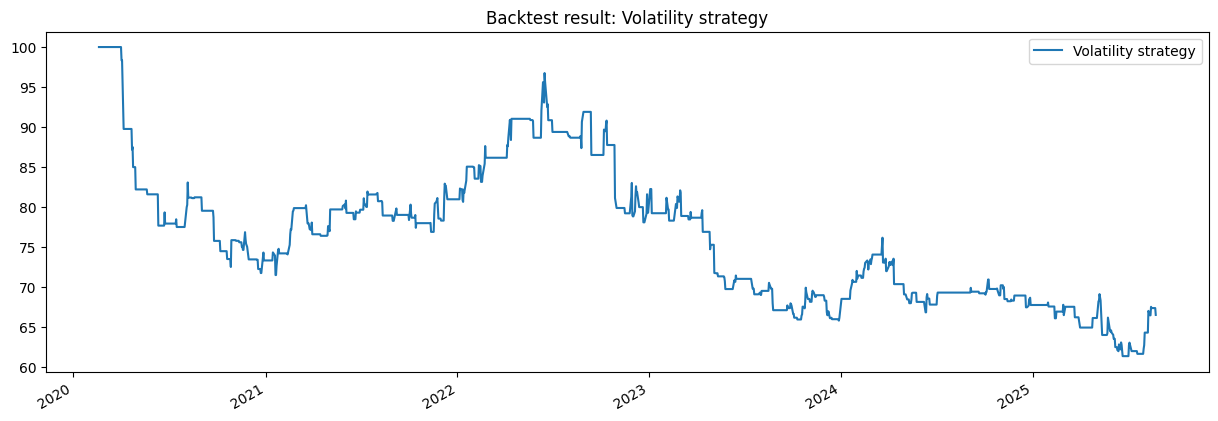

In [14]:
def backtest_strategy_bt(data: pd.DataFrame, signal_name: str, strategy_name: str):
    signal = data[signal_name].astype(float).to_frame().copy()
    signal.rename(columns = {signal_name:'Close'}, inplace = True)
    strategy = bt.Strategy(strategy_name, [bt.algos.WeighTarget(signal), bt.algos.Rebalance()])
    backtest = bt.Backtest(strategy, data)
    
    return backtest

data_bt = apple_stock_data 
data_bt['atr_signal'] = atr_signal['signal']
backtest_atr_bt = backtest_strategy_bt(data_bt, 'atr_signal', "Volatility strategy")

result = bt.run(backtest_atr_bt)

#Plot the backtest result
result.display()
result.plot(title='Backtest result: Volatility strategy')

100%|██████████| 1/1 [00:00<00:00,  6.37it/s]

Stat                 Volatility strategy
-------------------  ---------------------
Start                2020-02-19
End                  2025-08-22
Risk-free rate       0.00%

Total Return         -26.94%
Daily Sharpe         -0.24
Daily Sortino        -0.32
CAGR                 -5.54%
Max Drawdown         -33.84%
Calmar Ratio         -0.16

MTD                  1.65%
3m                   -2.81%
6m                   -9.70%
YTD                  -8.81%
1Y                   -11.48%
3Y (ann.)            -9.13%
5Y (ann.)            -3.21%
10Y (ann.)           -
Since Incep. (ann.)  -5.54%

Daily Sharpe         -0.24
Daily Sortino        -0.32
Daily Mean (ann.)    -4.18%
Daily Vol (ann.)     17.41%
Daily Skew           -1.48
Daily Kurt           16.28
Best Day             4.91%
Worst Day            -9.25%

Monthly Sharpe       -0.26
Monthly Sortino      -0.38
Monthly Mean (ann.)  -4.29%
Monthly Vol (ann.)   16.66%
Monthly Skew         -0.46
Monthly Kurt         2.81
Best Month           11.3

<Axes: title={'center': 'Backtest result: Volatility strategy'}>

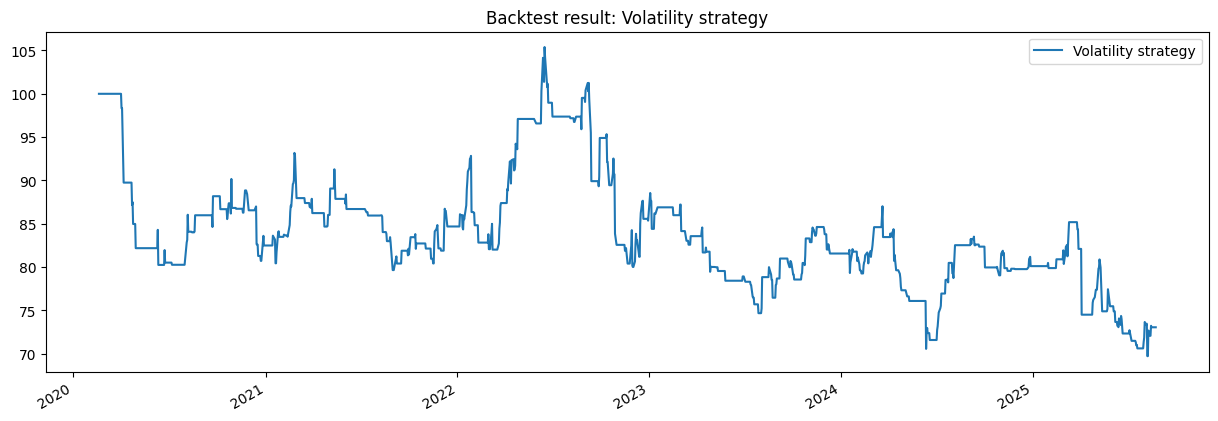

In [15]:
data_bt = apple_stock_data 
data_bt['vol_signal'] = atr_signal['signal_vol']
backtest_atr_bt = backtest_strategy_bt(data_bt, 'vol_signal', "Volatility strategy")

result = bt.run(backtest_atr_bt)

#Plot the backtest result
result.display()
result.plot(title='Backtest result: Volatility strategy')

In [10]:
def backtest_strategy_bt(data: pd.DataFrame, signal_name: str, strategy_name: str):
    data = data.copy()
    data.index = pd.to_datetime(data.index)

    # --- Clean price data ---
    if 'Close' not in data.columns:
        raise ValueError("Data must contain a 'Close' column")
    price_data = data[['Close']].copy()
    price_data['Close'].replace(0, np.nan, inplace=True)
    price_data['Close'].ffill(inplace=True)

    # --- Prepare weights ---
    if signal_name not in data.columns:
        raise ValueError(f"Signal '{signal_name}' not found")
    weights = data[[signal_name]].astype(float).copy()
    weights.columns = price_data.columns

    # --- Align indices (drop NaNs) ---
    price_data, weights = price_data.align(weights, join="inner")
    price_data.dropna(inplace=True)
    weights.dropna(inplace=True)

    # --- Strategy ---
    strategy = bt.Strategy(
        strategy_name, 
        [bt.algos.WeighTarget(weights), bt.algos.Rebalance()]
    )
    return bt.Backtest(strategy, price_data)

/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/804232323.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  price_data['Close'].replace(0, np.nan, inplace=True)
/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/804232323.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

Stat                 Volatility strategy
-------------------  ---------------------
Start                2020-02-19
End                  2025-08-22
Risk-free rate       0.00%

Total Return         -33.51%
Daily Sharpe         -0.43
Daily Sortino        -0.58
CAGR                 -7.15%
Max Drawdown         -38.67%
Calmar Ratio         -0.18

MTD                  6.03%
3m                   3.55%
6m                   -0.62%
YTD                  -1.83%
1Y                   -4.03%
3Y (ann.)            -9.14%
5Y (ann.)            -3.92%
10Y (ann.)           -
Since Incep. (ann.)  -7.15%

Daily Sharpe         -0.43
Daily Sortino        -0.58
Daily Mean (ann.)    -6.32%
Daily Vol (ann.)     14.79%
Daily Skew           -1.28
Daily Kurt           16.92
Best Day             4.63%
Worst Day            -8.72%

Monthly Sharpe       -0.47
Monthly Sortino      -0.65
Monthly Mean (ann.)  -6.43%
Monthly Vol (ann.)   13.73%
Monthly Skew         -1.04
Monthly Kurt         4.78
Best Month           8.87%


<Axes: title={'center': 'Backtest result: Volatility strategy'}>

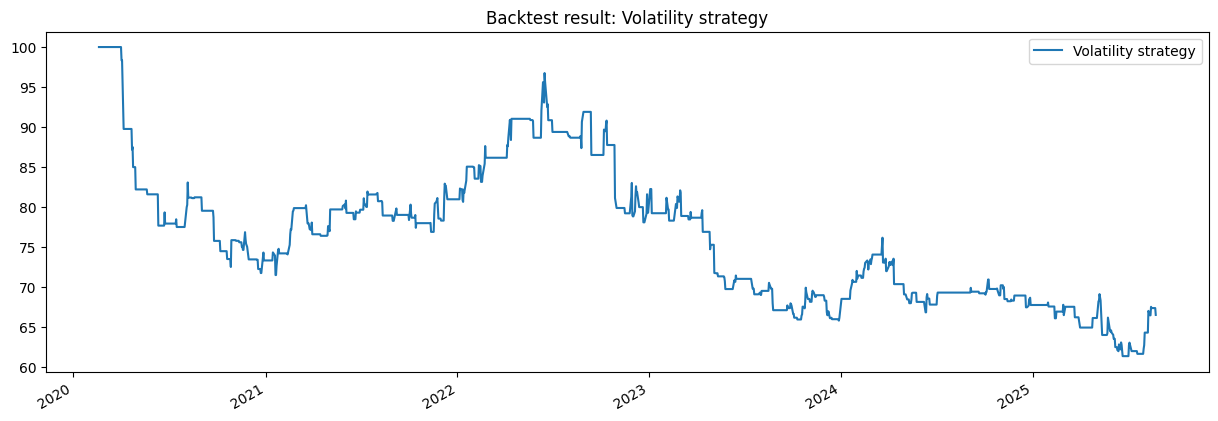

In [11]:
data_bt = apple_stock_data.copy()
data_bt['atr_signal'] = atr_signal['signal']

backtest_atr_bt = backtest_strategy_bt(data_bt, 'atr_signal', 'Volatility strategy')

result = bt.run(backtest_atr_bt)
result.display()
result.plot(title='Backtest result: Volatility strategy')

/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/804232323.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  price_data['Close'].replace(0, np.nan, inplace=True)
/var/folders/98/n7cbxwmj7z1cdgwpqvk8njpr0000gn/T/ipykernel_20486/804232323.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

100%|██████████| 1/1 [00:00<00:00,  7.73it/s]

Stat                 Volatility strategy
-------------------  ---------------------
Start                2020-02-19
End                  2025-08-22
Risk-free rate       0.00%

Total Return         -26.94%
Daily Sharpe         -0.24
Daily Sortino        -0.32
CAGR                 -5.54%
Max Drawdown         -33.84%
Calmar Ratio         -0.16

MTD                  1.65%
3m                   -2.81%
6m                   -9.70%
YTD                  -8.81%
1Y                   -11.48%
3Y (ann.)            -9.13%
5Y (ann.)            -3.21%
10Y (ann.)           -
Since Incep. (ann.)  -5.54%

Daily Sharpe         -0.24
Daily Sortino        -0.32
Daily Mean (ann.)    -4.18%
Daily Vol (ann.)     17.41%
Daily Skew           -1.48
Daily Kurt           16.28
Best Day             4.91%
Worst Day            -9.25%

Monthly Sharpe       -0.26
Monthly Sortino      -0.38
Monthly Mean (ann.)  -4.29%
Monthly Vol (ann.)   16.66%
Monthly Skew         -0.46
Monthly Kurt         2.81
Best Month           11.3

<Axes: title={'center': 'Backtest result: Volatility strategy'}>

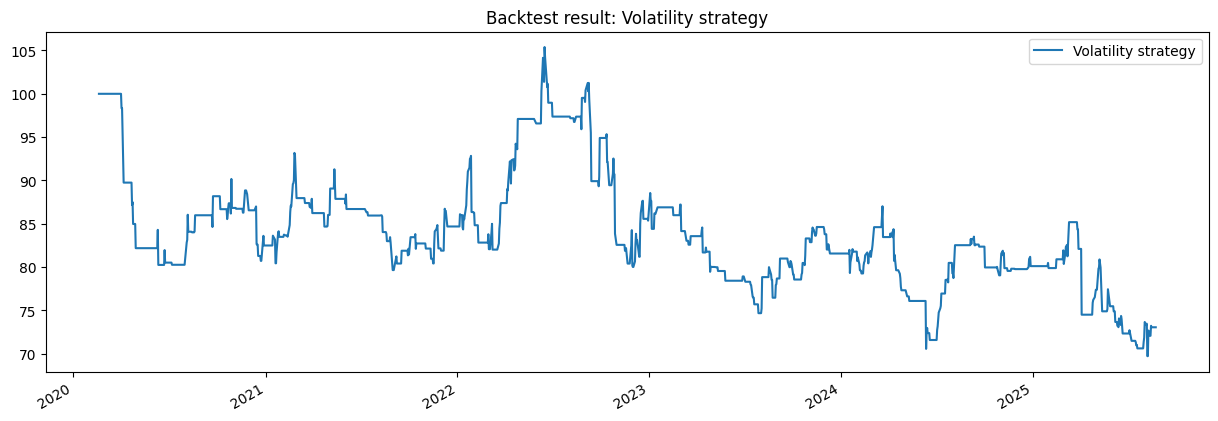

In [12]:
data_bt = apple_stock_data 
data_bt['volatility_signal'] = atr_signal['signal_vol']
backtest_atr_bt = backtest_strategy_bt(data_bt, 'volatility_signal', "Volatility strategy")

result = bt.run(backtest_atr_bt)

#Plot the backtest result
result.display()
result.plot(title='Backtest result: Volatility strategy')

In [2]:
a = 0.1+0.2
print(a == 0.3)

False
